In [1]:
from astropy.io import fits
from astropy.timeseries import LombScargle

import numpy as np
import matplotlib.pyplot as plt

from scipy.io import readsav
from sklearn.decomposition import PCA

from tqdm import tqdm

import tools as t

In [3]:
# load files
path_data = '../data/'
data_spectra = fits.getdata(path_data + 'flux_norm_paq12_6173_lionel_tau1_scalingspatial1_sansrotation.fits')
data_rv = readsav(path_data + 'res_rv_bis_6173_lionel_tau1_scaling1_sansrot.sav')

In [4]:
c = 3e8
# extract data
wl = data_rv['lambd']
rv = data_rv['rv_correl']
template = data_rv['flux_moy']
times = np.linspace(0, len(data_spectra) - 1, len(data_spectra))

In [5]:
spectra_matrix = data_spectra
# apply double centering to the spectra matrix
spectra_centered = t.double_centering(spectra_matrix)

In [6]:
# apply PCA to the centered spectra matrix
n_components = 20
pca_flux = PCA(n_components=n_components)  # create PCA object
pcs  = pca_flux.fit_transform(spectra_centered)  # fit the model with spectra_centered and apply the dimensionality reduction
var  = pca_flux.explained_variance_ratio_
print(f'Variance explained by the {n_components} components:', var)  # how much information (variance) can be attributed to each of the principal components

Variance explained by the 20 components: [9.92803806e-01 6.26560296e-03 8.63973395e-04 3.85380068e-05
 2.41456299e-05 2.64868120e-06 8.36598837e-07 1.80366280e-07
 1.30135383e-07 8.46910387e-08 2.39329689e-08 7.45164719e-09
 2.45115279e-09 1.75363266e-09 1.46686893e-09 3.01420518e-10
 2.33800456e-10 2.18477225e-10 2.13561898e-10 2.09785696e-10]


In [7]:
# component significance
# multiple realizations allow to calculate error bars

n_realizations = 20

# reduce the size of the data to reduce memory usage
spectra_centered = spectra_centered.astype(np.float32)
comps = pca_flux.components_.astype(np.float32)

simi_all = np.empty((n_realizations, n_components, n_components), dtype=np.float32)  # n_realizations squared matrices of n_components x n_components

for i in tqdm(range(n_realizations)):  # iterate over realizations
    spectra_noisy = spectra_centered + np.random.normal(0, .0000005, spectra_centered.shape)  # add gaussian noise to the original data

    pca_noisy = PCA(n_components=n_components, svd_solver="randomized")  # apply PCA to the noisy matrix
    pca_noisy.fit(spectra_noisy)

    comps_noisy = pca_noisy.components_  # save the loadings

    simi_all[i] = comps @ comps_noisy.T  # save dot product between original and noisy loadings

100%|██████████| 20/20 [00:00<00:00, 36.59it/s]


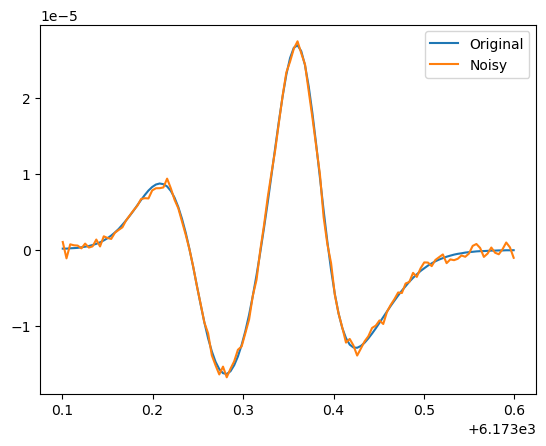

In [8]:
spectra_noisy = spectra_centered + np.random.normal(0, .0000005, len(wl))  # add gaussian noise to the original data
plt.plot(wl, spectra_centered[0], label='Original')
plt.plot(wl, spectra_noisy[0], label='Noisy')
plt.legend()
plt.show()

In [9]:
maxes = np.array([np.amax(s, axis=1) for s in simi_all])  # max of each row of each realization
mean_maxes = np.array([(np.average(s), np.std(s)) for s in maxes.T])  # list of max mean and std for each PC: [(max_avg_1, max_std_1), (max_avg_2, max_std_2), ..., (max_avg_n, max_std_n)]

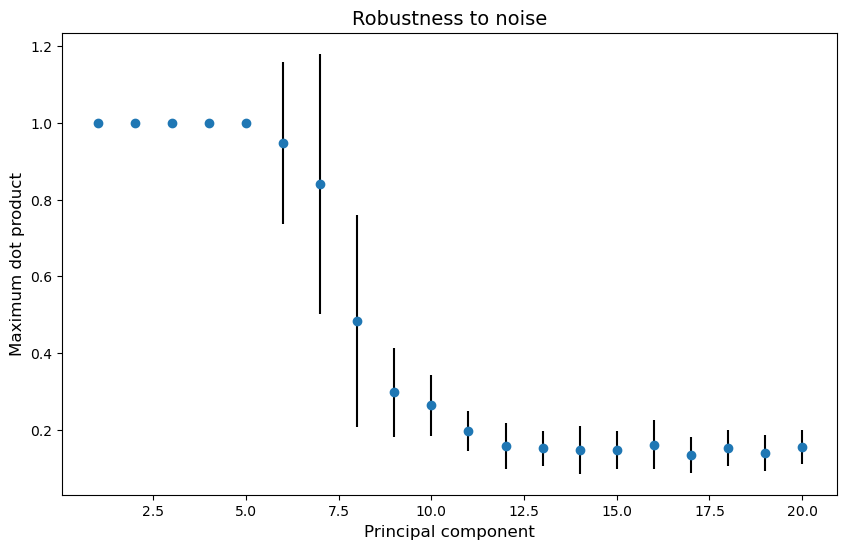

In [10]:
# plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.errorbar(np.linspace(1, n_components, n_components), mean_maxes[:, 0], mean_maxes[:, 1], fmt='o', ecolor='k')
ax.set_title('Robustness to noise', size=14)
ax.set_xlabel('Principal component', size=12)
ax.set_ylabel('Maximum dot product', size=12)
plt.show()

In [11]:
#sp = [np.fft.fft(pcs[:, i]) for i in range(n_components)]
#freq = [np.fft.fftfreq(pcs[:, i].shape[-1]) for i in range(n_components)]

periodograms = [LombScargle(times, pcs[:, i]).autopower() for i in range(n_components)]

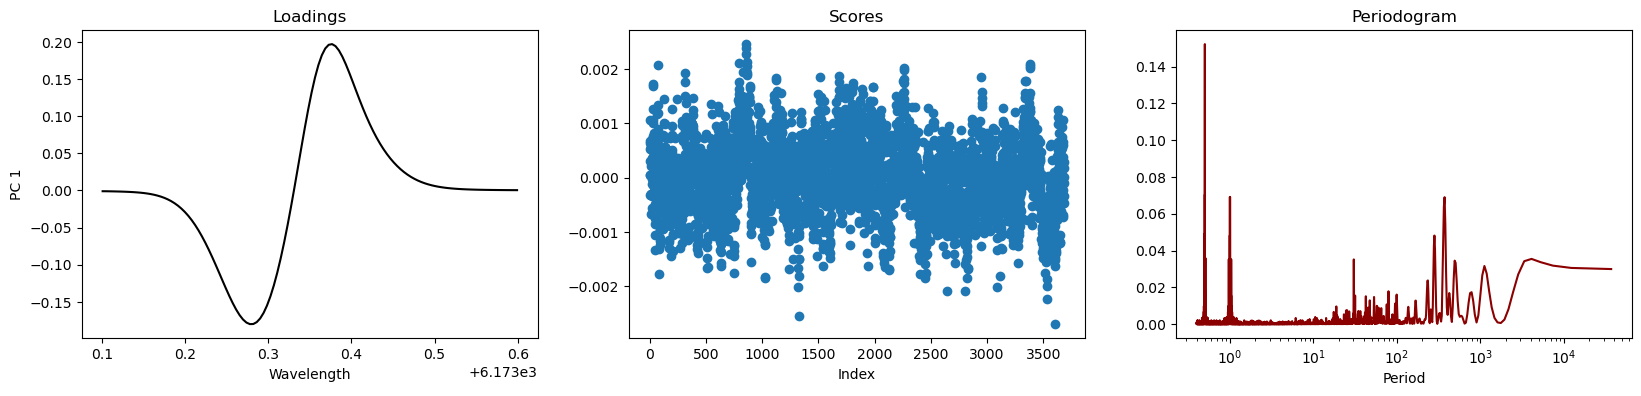

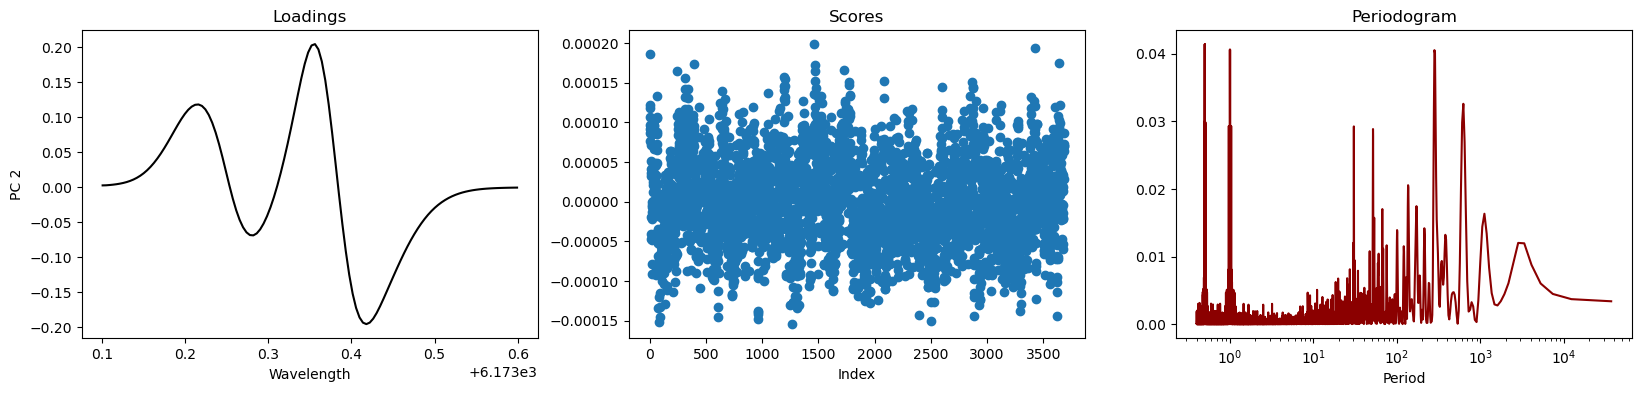

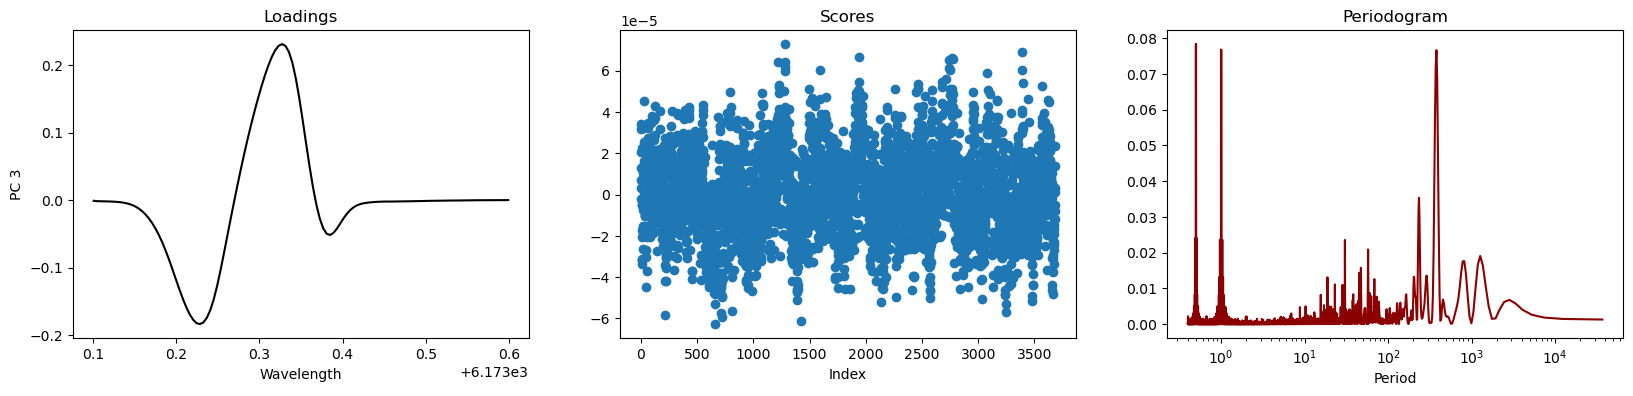

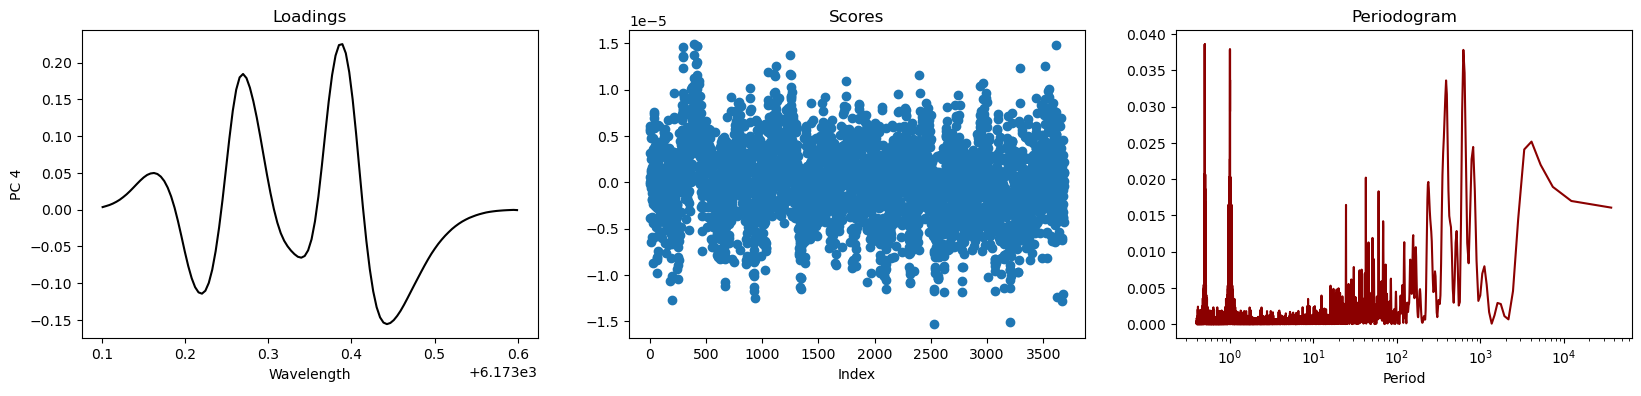

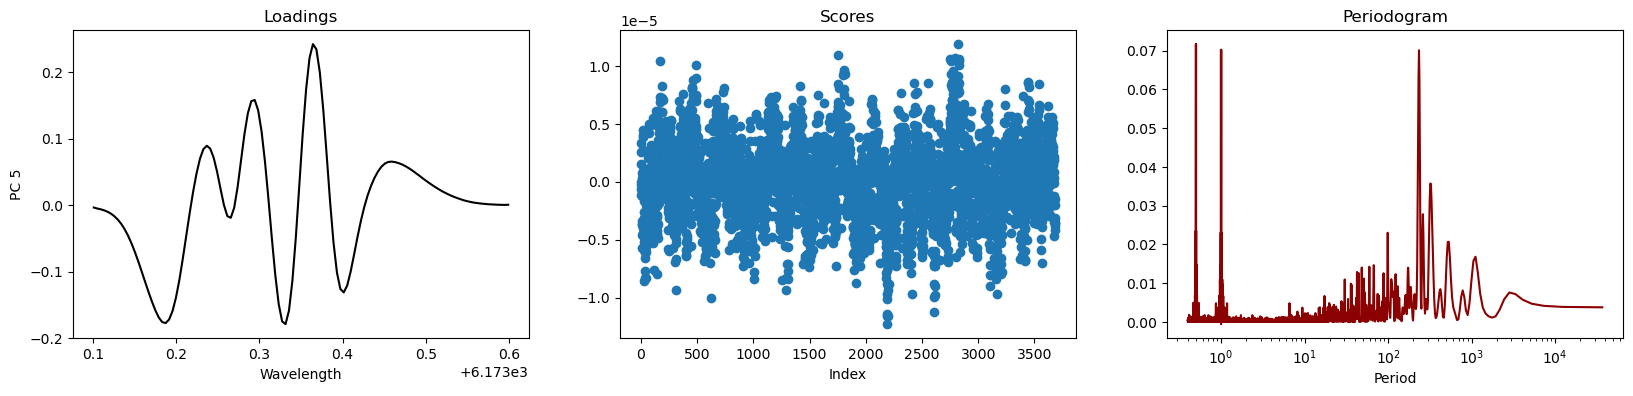

In [12]:
# plot
for i in range(5):
    fig, axs = plt.subplots(1, 3, figsize=(20, 4))
    
    # Loadings
    axs[0].plot(wl, pca_flux.components_[i], color='k')
    axs[0].set_title('Loadings', size=12)
    axs[0].set_xlabel('Wavelength')
    axs[0].set_ylabel(f'PC {i + 1}')
    
    # Scores
    axs[1].scatter(times, pcs[:, i])
    axs[1].set_title('Scores', size=12)
    axs[1].set_xlabel('Index')

    # Fourier periodogram
    axs[2].plot(1 / periodograms[i][0], periodograms[i][1], color='darkred')
    #axs[2].plot(freq[i] , sp[i].real, color='darkred')
    axs[2].set_xscale('log')
    axs[2].set_title('Periodogram', size=12)
    axs[2].set_xlabel('Period')
    
    plt.show()